# 03 · Repeat behaviour

**Questions answered.** (1) What share of each cohort buys again, and how long does the second purchase take?
(2) Do newer cohorts repeat more or less than older ones, like-for-like? (4) How much revenue comes from repeat
orders versus first orders?

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Markdown, display
from retention import config, core, plots

%matplotlib inline
pd.set_option("display.max_columns", 30, "display.width", 160, "display.float_format", "{:,.4f}".format)
WINDOW = 90   # repeat-purchase window (days) for the headline metric

In [2]:
lines = pd.read_parquet(config.LINES_PARQUET)
bounds = core.period_bounds(lines)
orders = core.build_orders(lines)
customers = core.build_customers(orders, bounds)
print(f"{len(lines):,} line items -> {len(orders):,} orders from {len(customers):,} customers")
print({k: str(v) for k, v in bounds.items()})

802,632 line items -> 36,594 orders from 5,852 customers
{'data_end': '2011-12-09 12:50:00', 'first_month': '2009-12', 'last_complete_month': '2011-11', 'last_month': '2011-12'}


## 1. Cohort summary: two repeat rates, only one of them fair

In [3]:
col = f"Repeat{WINDOW}d"
summary = core.cohort_summary(customers, bounds, WINDOW)
summary.style.format({"CohortSize": "{:,.0f}", "RepeatEver": "{:.1%}", col: "{:.1%}", "AvgOrders": "{:.2f}",
                      "MedianFirstOrderValue": "£{:,.0f}", "RevenuePerCustomer": "£{:,.0f}",
                      f"MedianDaysToSecond_{WINDOW}d": "{:.0f}"}, na_rep="-")

,CohortSize,RepeatEver,AvgOrders,MedianFirstOrderValue,RevenuePerCustomer,Repeat90d,MedianDaysToSecond_90d,FullyObserved
CohortMonth,,,,,,,,
2009-12,951,91.3%,15.94,£303,"£8,957",61.5%,25,True
2010-01,368,89.7%,8.40,£299,"£3,546",54.1%,38,True
2010-02,375,84.3%,6.69,£306,"£2,643",51.7%,36,True
2010-03,441,82.5%,6.51,£304,"£2,982",43.8%,42,True
2010-04,294,78.6%,5.11,£301,"£1,848",39.8%,35,True
2010-05,255,78.4%,4.40,£267,"£1,526",36.9%,33,True
2010-06,267,75.3%,4.46,£287,"£2,243",38.6%,30,True
2010-07,185,75.1%,5.14,£242,"£1,654",45.4%,34,True
2010-08,163,71.2%,4.47,£290,"£1,532",52.8%,38,True


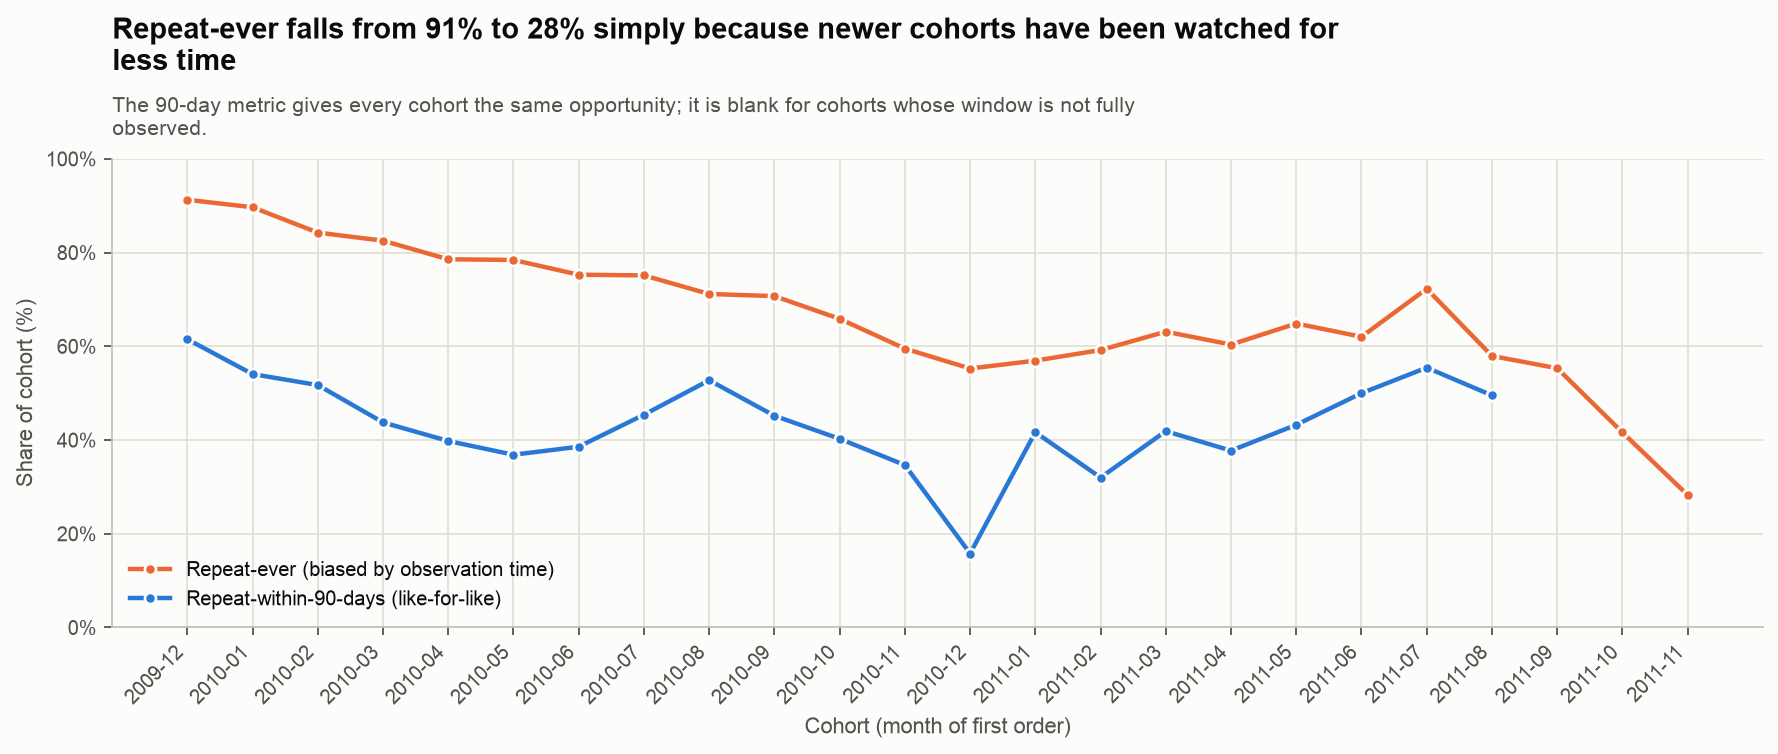

In [4]:
plots.repeat_ever_vs_window(summary, WINDOW)

In [5]:
display(Markdown(
    f"### Why repeat-ever is misleading\n\n"
    f"Repeat-ever falls almost monotonically from **{summary['RepeatEver'].iloc[0]:.1%}** for the "
    f"{summary.index[0]} cohort to **{summary['RepeatEver'].iloc[-1]:.1%}** for {summary.index[-1]}. That is not "
    f"customers getting worse. The {summary.index[0]} cohort has been watched for about "
    f"{(bounds['data_end'] - summary.index[0].start_time).days} days; the {summary.index[-1]} cohort for at most "
    f"{(bounds['data_end'] - summary.index[-1].start_time).days}. 'Ever' simply means 'so far', so the metric "
    f"mostly measures **how long we have been watching** (right-censoring, trap 2).\n\n"
    f"**Repeat-within-{WINDOW}-days** gives every customer the same {WINDOW}-day opportunity. It is filled only "
    f"for cohorts whose last joiner has a full {WINDOW} days inside the data - "
    f"**{int(summary['FullyObserved'].sum())} of {len(summary)}** cohorts - and left blank for the rest. "
    f"On that fair basis there is no downward trend: the earliest true-new cohort is at "
    f"{summary[col].iloc[1]:.1%} and the latest fully observed one at {summary[col].dropna().iloc[-1]:.1%}. "
    f"Cohorts are never ranked on repeat-ever in this project."))

### Why repeat-ever is misleading

Repeat-ever falls almost monotonically from **91.3%** for the 2009-12 cohort to **28.3%** for 2011-11. That is not customers getting worse. The 2009-12 cohort has been watched for about 738 days; the 2011-11 cohort for at most 38. 'Ever' simply means 'so far', so the metric mostly measures **how long we have been watching** (right-censoring, trap 2).

**Repeat-within-90-days** gives every customer the same 90-day opportunity. It is filled only for cohorts whose last joiner has a full 90 days inside the data - **21 of 24** cohorts - and left blank for the rest. On that fair basis there is no downward trend: the earliest true-new cohort is at 54.1% and the latest fully observed one at 49.5%. Cohorts are never ranked on repeat-ever in this project.

## 2. Repeat-within-90-days by cohort (the headline metric)

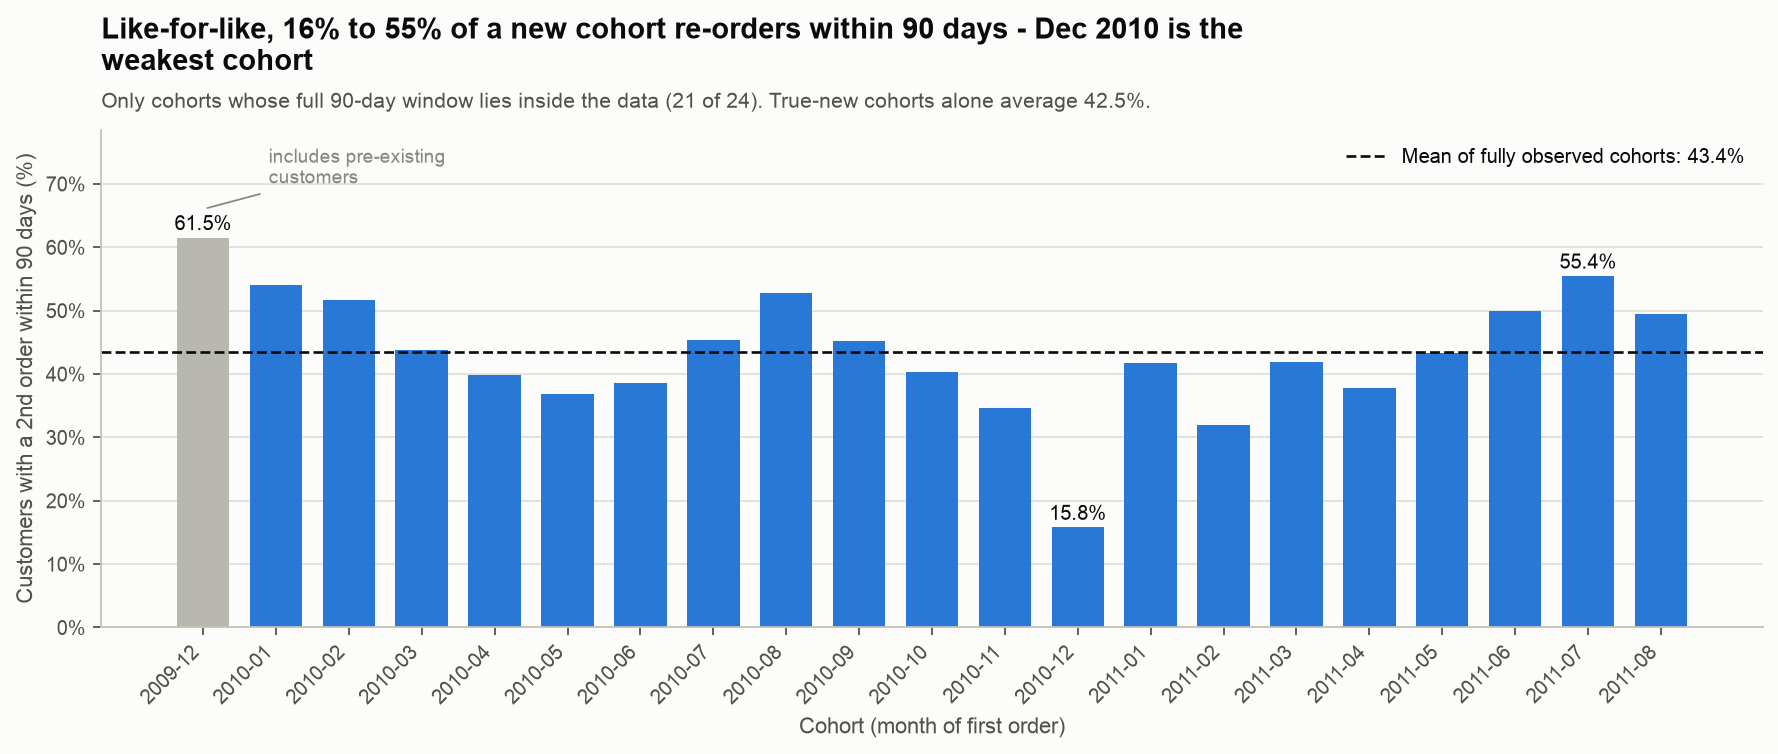

In [6]:
plots.repeat_window_by_cohort(summary, bounds["first_month"], WINDOW)

In [7]:
full = summary.loc[summary["FullyObserved"], col]
true_new = full[full.index > bounds["first_month"]]
display(Markdown(
    f"- Mean over the {len(full)} fully observed cohorts: **{full.mean():.1%}** "
    f"(range {full.min():.1%} - {full.max():.1%}).\n"
    f"- The top of that range is the left-censored {full.index[0]} cohort. Over the {len(true_new)} **true-new** "
    f"fully observed cohorts the mean is **{true_new.mean():.1%}** (range {true_new.min():.1%} - "
    f"{true_new.max():.1%}).\n"
    f"- Weakest: **{true_new.idxmin()}** at {true_new.min():.1%} (only {int(summary.loc[true_new.idxmin(), 'CohortSize'])} "
    f"customers, so it is also the noisiest). Strongest true-new: **{true_new.idxmax()}** at "
    f"{true_new.max():.1%}.\n"
    f"- There is no steady improvement or decline over time; the variation is seasonal and cohort-specific."))

- Mean over the 21 fully observed cohorts: **43.4%** (range 15.8% - 61.5%).
- The top of that range is the left-censored 2009-12 cohort. Over the 20 **true-new** fully observed cohorts the mean is **42.5%** (range 15.8% - 55.4%).
- Weakest: **2010-12** at 15.8% (only 76 customers, so it is also the noisiest). Strongest true-new: **2011-07** at 55.4%.
- There is no steady improvement or decline over time; the variation is seasonal and cohort-specific.

## 3. Time to second order — Kaplan–Meier

A plain "% who repeated" treats a customer who joined last week and has not yet returned as a non-repeater.
The Kaplan–Meier estimator instead **censors** them at the end of their observation window: they count in the
denominator only for the days we actually watched them.

,share with a 2nd order by day
day,
30,22.8%
60,38.1%
90,47.4%
180,63.1%
365,74.9%


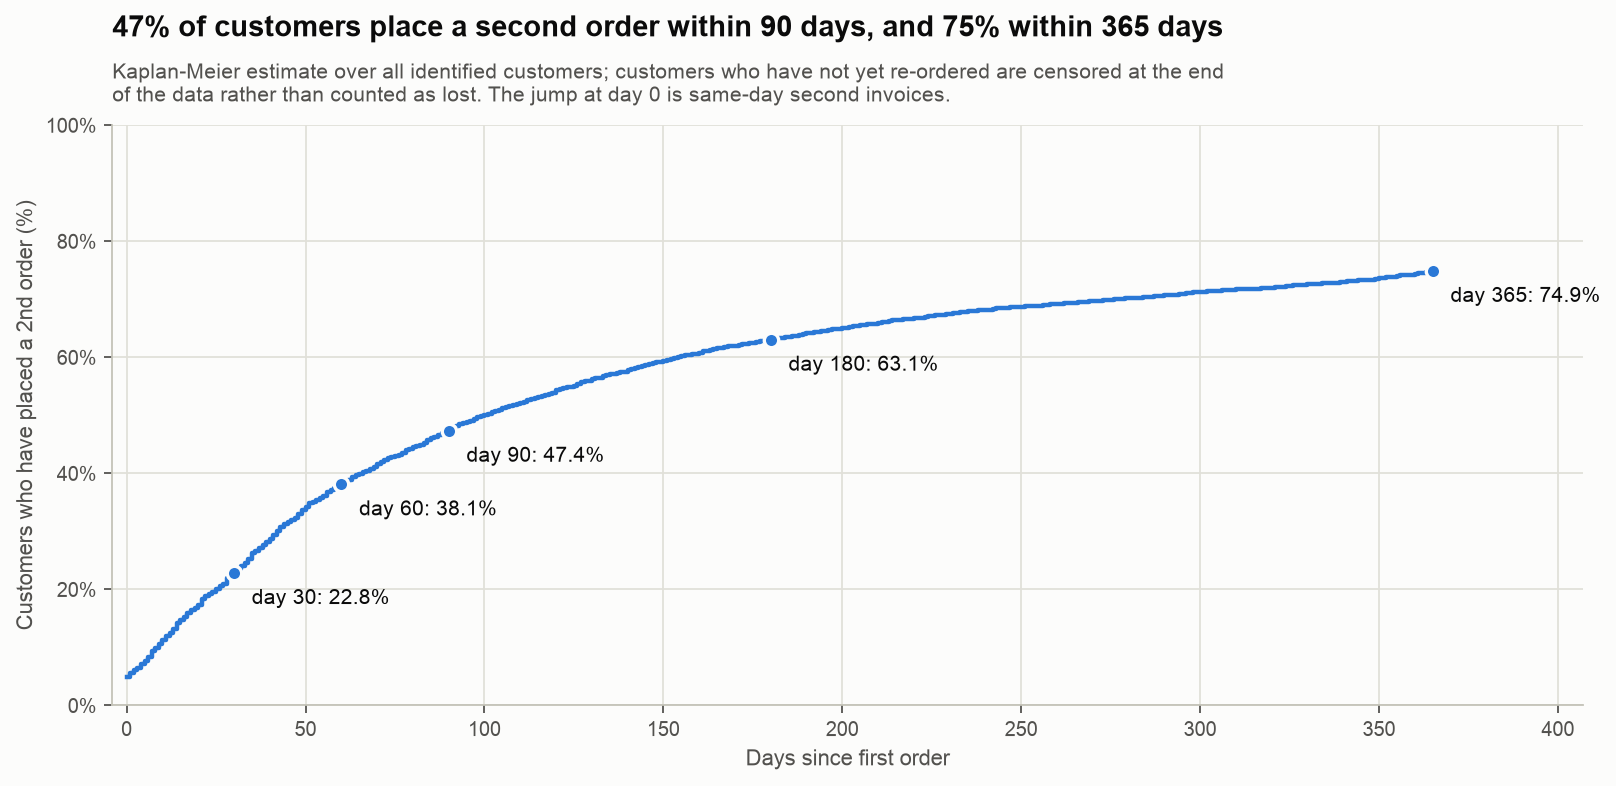

In [8]:
km = core.survival_to_second(customers)
readings = core.repeat_by_day(km, core.KM_DAYS)
display(pd.Series(readings, name="share with a 2nd order by day").rename_axis("day").to_frame().style.format("{:.1%}"))
plots.survival_to_second(km, readings)

### Cross-check against `lifelines`

The implementation in `core.survival_to_second` is self-contained; if `lifelines` is installed it should agree to floating-point precision.

In [9]:
import numpy as np
try:
    from lifelines import KaplanMeierFitter
    duration = np.where(customers["IsRepeat"], customers["DaysToSecond"], customers["ObservedDays"])
    kmf = KaplanMeierFitter().fit(duration.astype(float), event_observed=customers["IsRepeat"])
    theirs = 1 - kmf.survival_function_at_times(km["day"]).to_numpy()
    gap = float(np.abs(theirs - km["repeated_by"].to_numpy()).max())
    print(f"max absolute difference vs lifelines over {len(km)} time points: {gap:.2e}")
    assert gap < 1e-9
    print("curves agree")
except ImportError:
    print("lifelines not installed - cross-check skipped (the core implementation is self-contained)")

max absolute difference vs lifelines over 358 time points: 2.33e-15
curves agree


## 4. Days to second order

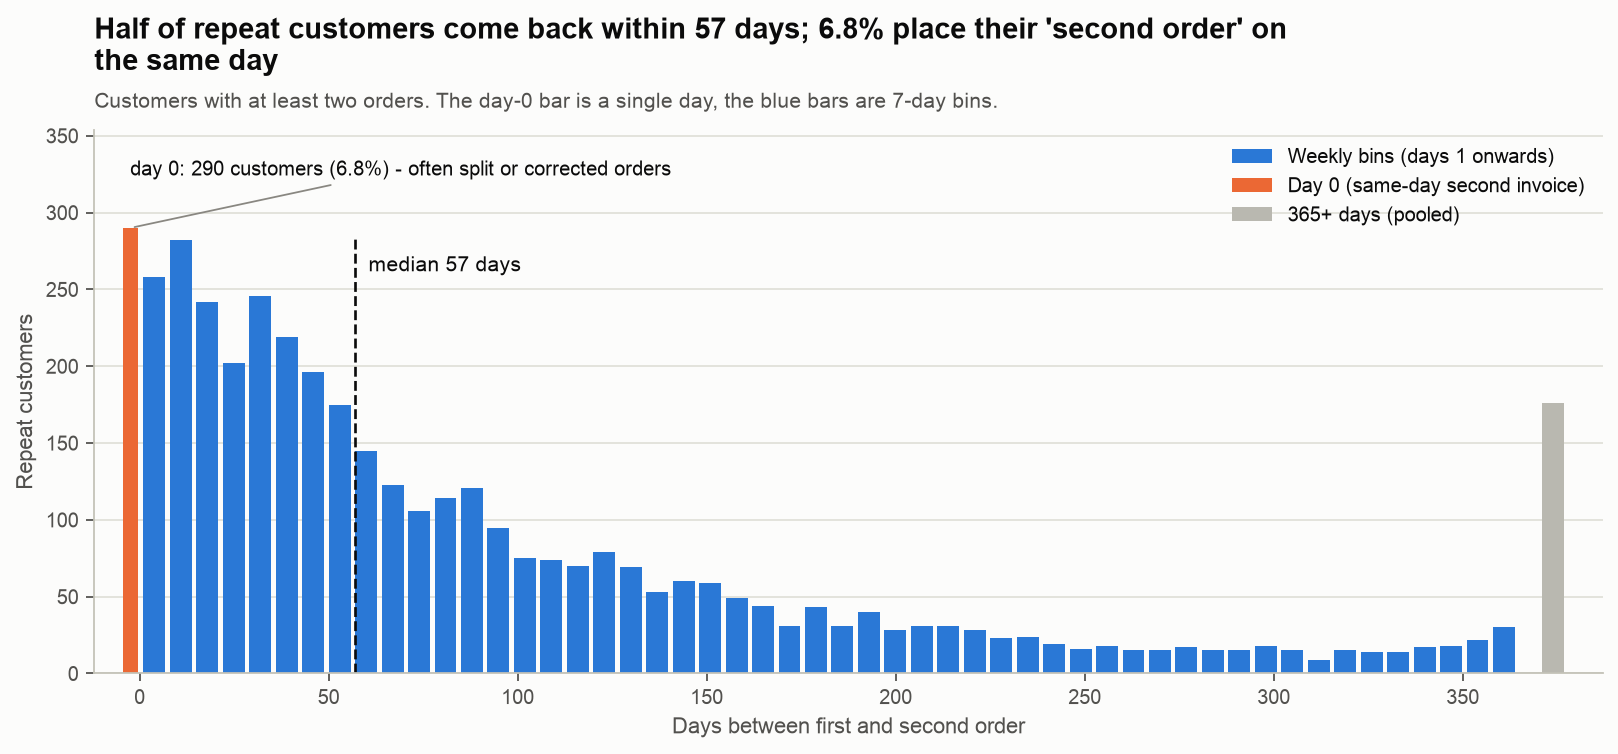

In [10]:
repeaters = customers[customers["IsRepeat"]]
hist = core.days_to_second_hist(customers)
median_days = float(repeaters["DaysToSecond"].median())
same_day = float((repeaters["DaysToSecond"] == 0).mean())
plots.days_to_second_hist(hist, median_days, same_day)

In [11]:
q = repeaters["DaysToSecond"].quantile([0.25, 0.5, 0.75])
later = repeaters.loc[repeaters["DaysToSecond"] > 0, "DaysToSecond"]
display(Markdown(
    f"Among the {len(repeaters):,} customers with at least two orders, the median gap is **{median_days:.0f} days** "
    f"(quartiles {q[0.25]:.0f} / {q[0.5]:.0f} / {q[0.75]:.0f}); the mean is {repeaters['DaysToSecond'].mean():.0f} "
    f"days because of a long tail.\n\n"
    f"**Same-day spike (trap 6).** {int((repeaters['DaysToSecond'] == 0).sum()):,} of them ({same_day:.1%}) placed "
    f"their second invoice on the *same day* as the first. These are often split or corrected orders rather than "
    f"genuine re-purchases. They are kept (dropping them would need a rule the data cannot justify), but note "
    f"that excluding them the median would be {later.median():.0f} days."))

Among the 4,234 customers with at least two orders, the median gap is **57 days** (quartiles 21 / 57 / 133); the mean is 99 days because of a long tail.

**Same-day spike (trap 6).** 290 of them (6.8%) placed their second invoice on the *same day* as the first. These are often split or corrected orders rather than genuine re-purchases. They are kept (dropping them would need a rule the data cannot justify), but note that excluding them the median would be 64 days.

## 5. Two repeat numbers that disagree — and why (trap 9)

In [12]:
display(Markdown(
    f"| Metric | Value | Who is counted | Weighting |\n|---|---|---|---|\n"
    f"| Cohort repeat-within-{WINDOW}-days (mean) | **{full.mean():.1%}** | {len(full)} cohorts whose {WINDOW}-day "
    f"window is fully observed; the last {len(summary) - len(full)} cohorts are left out | each cohort counts "
    f"equally |\n"
    f"| Kaplan-Meier at day {WINDOW} | **{readings[str(WINDOW)]:.1%}** | all {len(customers):,} customers, "
    f"non-repeaters censored | each customer counts equally |\n\n"
    f"Both are correct. They differ by {(readings[str(WINDOW)] - full.mean()) * 100:.1f} pp because KM pools "
    f"every customer and so is dominated by the big early cohorts - above all the left-censored "
    f"{summary.index[0]} cohort ({int(summary['CohortSize'].iloc[0]):,} customers, "
    f"{summary[col].iloc[0]:.1%}) - whereas the cohort mean gives the {int(summary['CohortSize'].min())}-customer "
    f"cohort the same weight as the {int(summary['CohortSize'].iloc[0]):,}-customer one. Use the cohort metric to "
    f"compare cohorts and the KM curve to describe *when* customers come back."))

| Metric | Value | Who is counted | Weighting |
|---|---|---|---|
| Cohort repeat-within-90-days (mean) | **43.4%** | 21 cohorts whose 90-day window is fully observed; the last 3 cohorts are left out | each cohort counts equally |
| Kaplan-Meier at day 90 | **47.4%** | all 5,852 customers, non-repeaters censored | each customer counts equally |

Both are correct. They differ by 3.9 pp because KM pools every customer and so is dominated by the big early cohorts - above all the left-censored 2009-12 cohort (951 customers, 61.5%) - whereas the cohort mean gives the 72-customer cohort the same weight as the 951-customer one. Use the cohort metric to compare cohorts and the KM curve to describe *when* customers come back.

## 6. Revenue: first orders vs repeat orders

OrderType,First,Repeat,Total,RepeatShare
CohortMonth,,,,
2009-12,"£399,329","£8,118,734","£8,518,063",95.3%
2010-01,"£144,468","£1,160,448","£1,304,916",88.9%
2010-02,"£148,090","£843,212","£991,301",85.1%
2010-03,"£178,148","£1,136,869","£1,315,017",86.5%
2010-04,"£117,826","£425,467","£543,292",78.3%
2010-05,"£102,047","£287,189","£389,236",73.8%
2010-06,"£115,739","£483,031","£598,770",80.7%
2010-07,"£58,503","£247,421","£305,924",80.9%
2010-08,"£55,974","£193,701","£249,675",77.6%


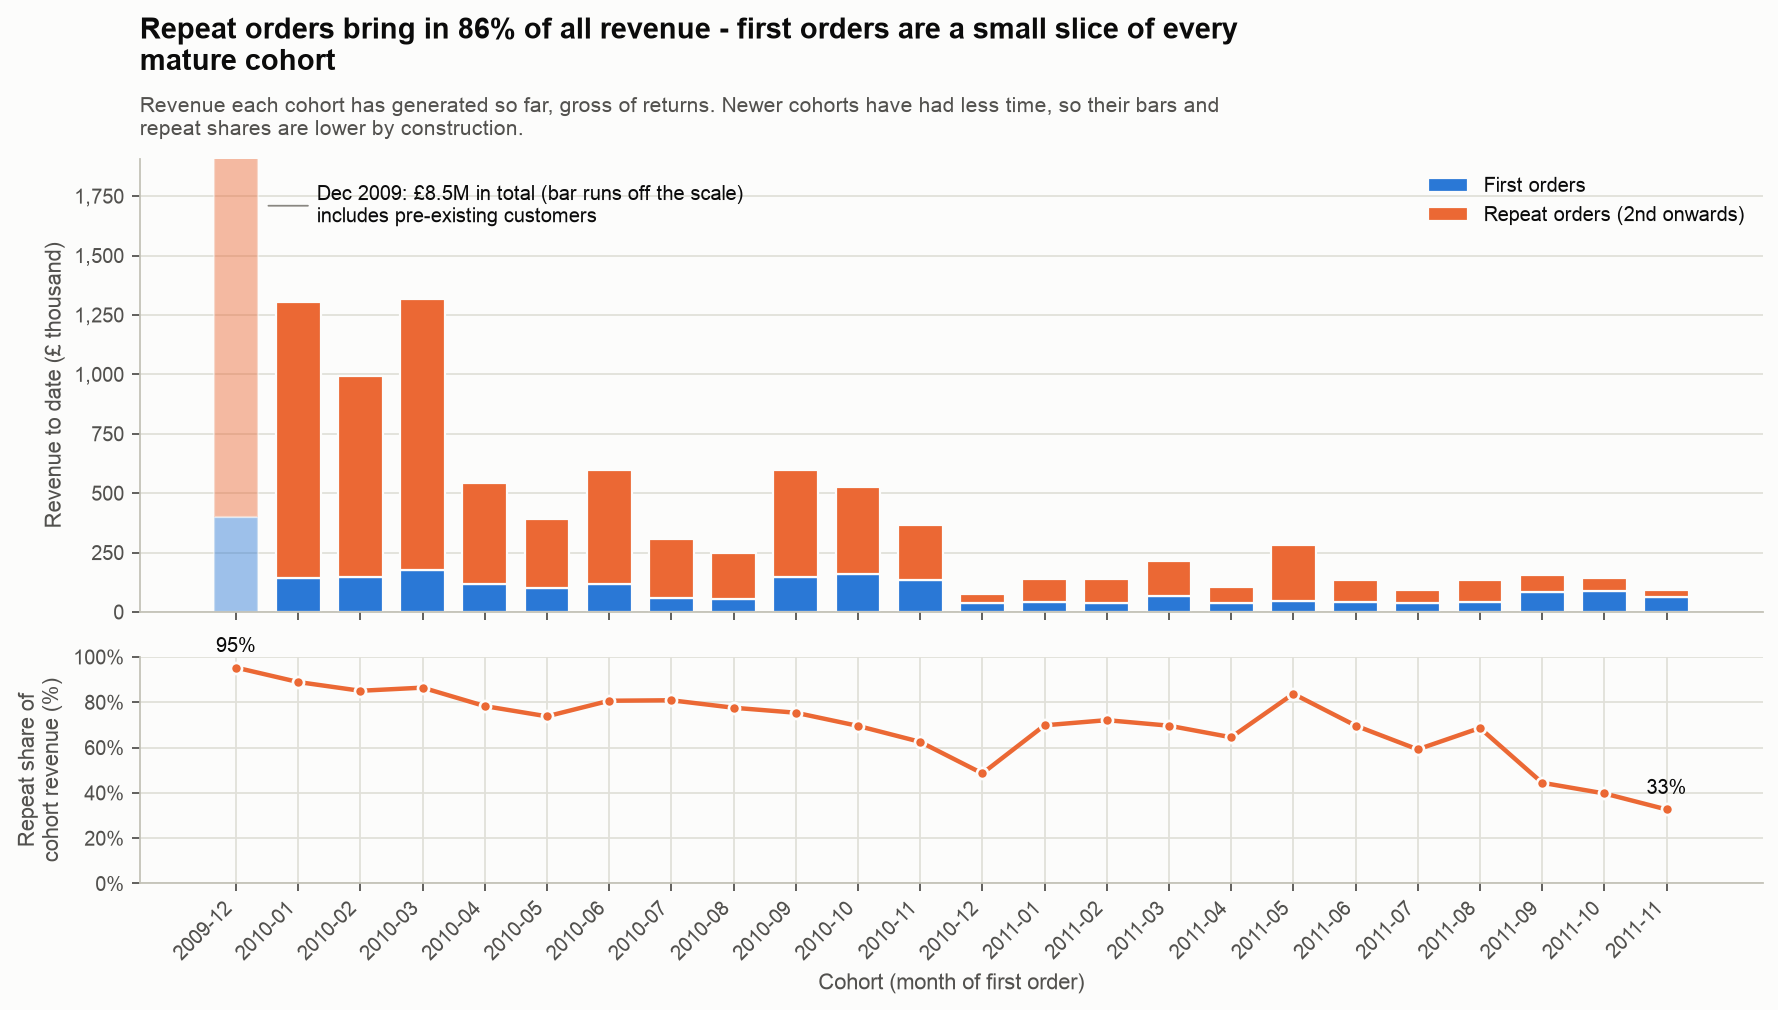

In [13]:
split = core.revenue_split(orders, bounds)
display(split.style.format({"First": "£{:,.0f}", "Repeat": "£{:,.0f}", "Total": "£{:,.0f}", "RepeatShare": "{:.1%}"}))
plots.revenue_split(split, bounds["first_month"])

In [14]:
repeat_rev = orders.loc[orders["OrderNumber"] > 1].groupby("CustomerID")["Revenue"].sum()
tn = split.loc[split.index > bounds["first_month"]]
display(Markdown(
    f"Repeat orders account for **{split['Repeat'].sum() / split['Total'].sum():.1%}** of revenue "
    f"(£{split['Repeat'].sum():,.0f} of £{split['Total'].sum():,.0f}). Excluding the left-censored "
    f"{split.index[0]} cohort the share is still {tn['Repeat'].sum() / tn['Total'].sum():.1%}.\n\n"
    f"Revenue is gross of returns (cancellations are dropped, not netted off - trap 5), and it is concentrated: "
    f"repeat revenue per repeat customer has a **median of £{repeat_rev.median():,.0f}** but a mean of "
    f"£{repeat_rev.mean():,.0f} because of wholesale buyers (trap 8). The lower repeat share of recent cohorts "
    f"is again an observation-time effect, not a quality signal."))

Repeat orders account for **86.3%** of revenue (£15,024,229 of £17,410,953). Excluding the left-censored 2009-12 cohort the share is still 77.7%.

Revenue is gross of returns (cancellations are dropped, not netted off - trap 5), and it is concentrated: repeat revenue per repeat customer has a **median of £1,002** but a mean of £3,549 because of wholesale buyers (trap 8). The lower repeat share of recent cohorts is again an observation-time effect, not a quality signal.

## 7. Cumulative revenue per customer by cohort age

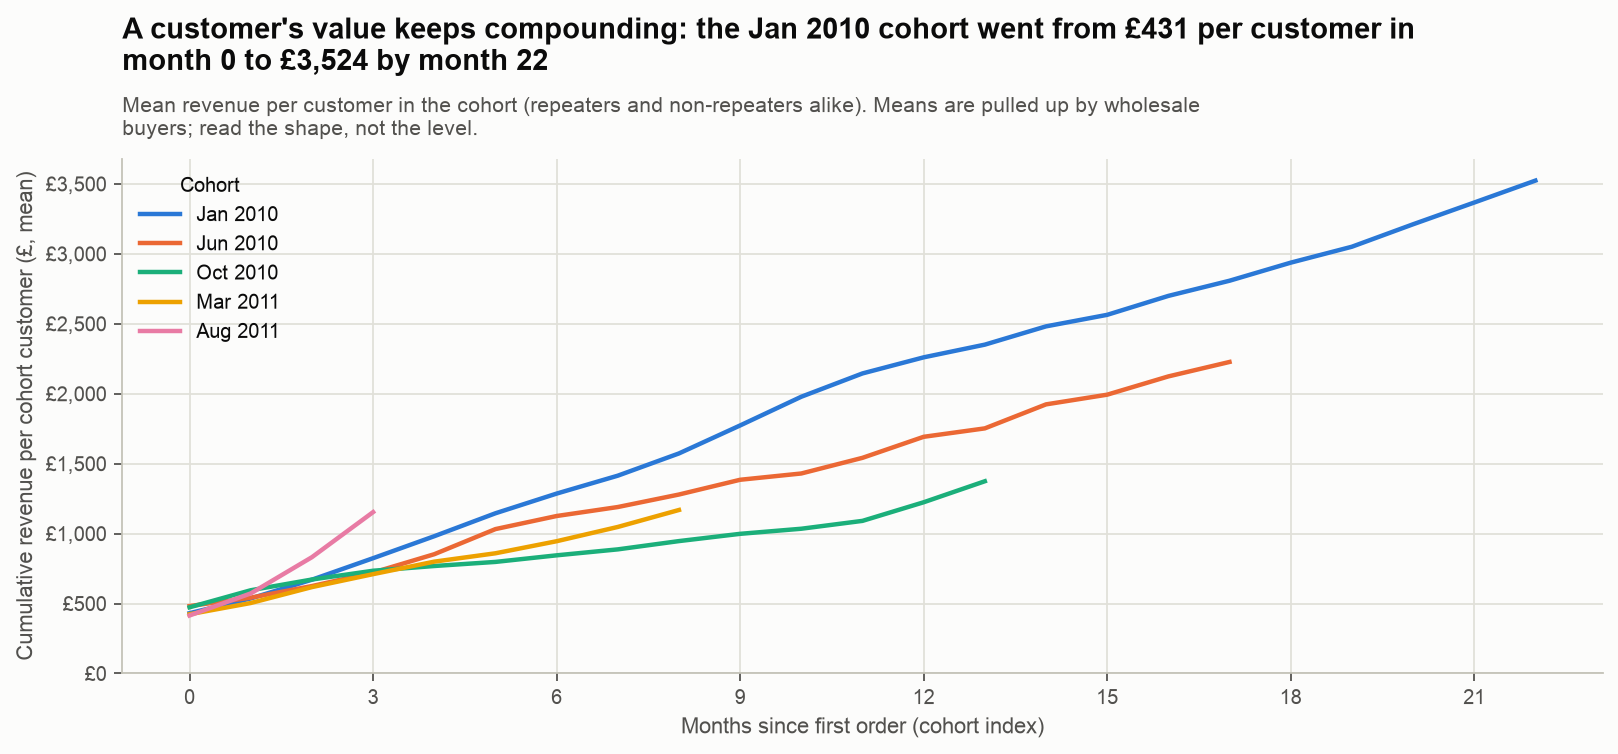

In [15]:
cum = core.cumulative_revenue_per_customer(orders, bounds)
selected = core.select_cohorts(summary, bounds, WINDOW)
plots.cumulative_revenue_curves(cum, selected)

The curves keep rising for as long as each cohort is observed: the value of an acquired customer is realised over many months, which is why the first-month drop-off matters so much.